# CJTP EDA — line × year heatmap

Customer Journey Time Performance is the share of rider trips completed
within five minutes of schedule. It's MTA's own answer to the question
a rider actually asks: "did I get there on time?" — not "did the train
hit the terminal on time?" Higher is better.

This notebook validates the rider hunch that the system is unevenly
reliable, line by line. We start with the headline view: a line × year
grid of mean CJTP, peak hours only.

In [1]:
import os
os.getcwd()

'/Users/Administrator/Documents/please-stand-clear-of-the-closing-data/code'

In [2]:
import sys
sys.path.append("../code")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from utils import MTA_COLORS, MAIN_LINES

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")
FIGURES = Path("../output/figures")
PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RAW / "cjm_2015_present.csv", parse_dates=["month"])
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)
df["year"] = df["month"].dt.year
df.shape, df["month"].min(), df["month"].max()

((5624, 13),
 Timestamp('2015-01-01 00:00:00'),
 Timestamp('2026-03-01 00:00:00'))

In [3]:
df["line"].value_counts().sort_index()

line
1         270
2         270
3         270
4         270
5         270
6         270
7         270
A         218
B         214
C         216
D         218
E         218
F         218
G         218
JZ        218
L         218
M         218
N         218
Q         218
R         218
S 42nd    256
S Fkln    218
S Rock    218
W         214
Name: count, dtype: int64

In [4]:
peak = df[df["period"] == "peak"].copy()
main_lines = ["1","2","3","4","5","6","7",
              "A","B","C","D","E","F","G",
              "JZ","L","M","N","Q","R","W",
              "S 42nd"]
peak = peak[peak["line"].isin(main_lines)]

heat = (
    peak
    .groupby(["line","year"])["customer_journey_time_performance"]
    .mean()
    .unstack("year")
    .reindex(main_lines)
)
heat.round(3)

year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
line,,,,,,,,,,,,
1,0.890,0.883,0.880,0.871,0.905,0.914,0.904,0.909,0.897,0.888,0.903,0.905
2,0.820,0.803,0.788,0.846,0.884,0.888,0.887,0.880,0.878,0.871,0.863,0.865
3,0.876,0.868,0.848,0.889,0.912,0.905,0.902,0.898,0.893,0.890,0.887,0.885
4,0.760,0.757,0.763,0.828,0.863,0.896,0.891,0.879,0.887,0.877,0.889,0.889
5,0.731,0.733,0.737,0.821,0.865,0.885,0.891,0.873,0.890,0.880,0.884,0.871
6,0.817,0.821,0.827,0.838,0.869,0.895,0.902,0.881,0.886,0.865,0.896,0.871
7,0.840,0.829,0.795,0.794,0.894,0.908,0.897,0.896,0.898,0.914,0.911,0.908
A,NaN,NaN,0.748,0.775,0.809,0.850,0.830,0.826,0.836,0.838,0.866,0.833
B,NaN,NaN,0.730,0.744,0.757,0.788,0.766,0.768,0.781,0.765,0.787,0.773


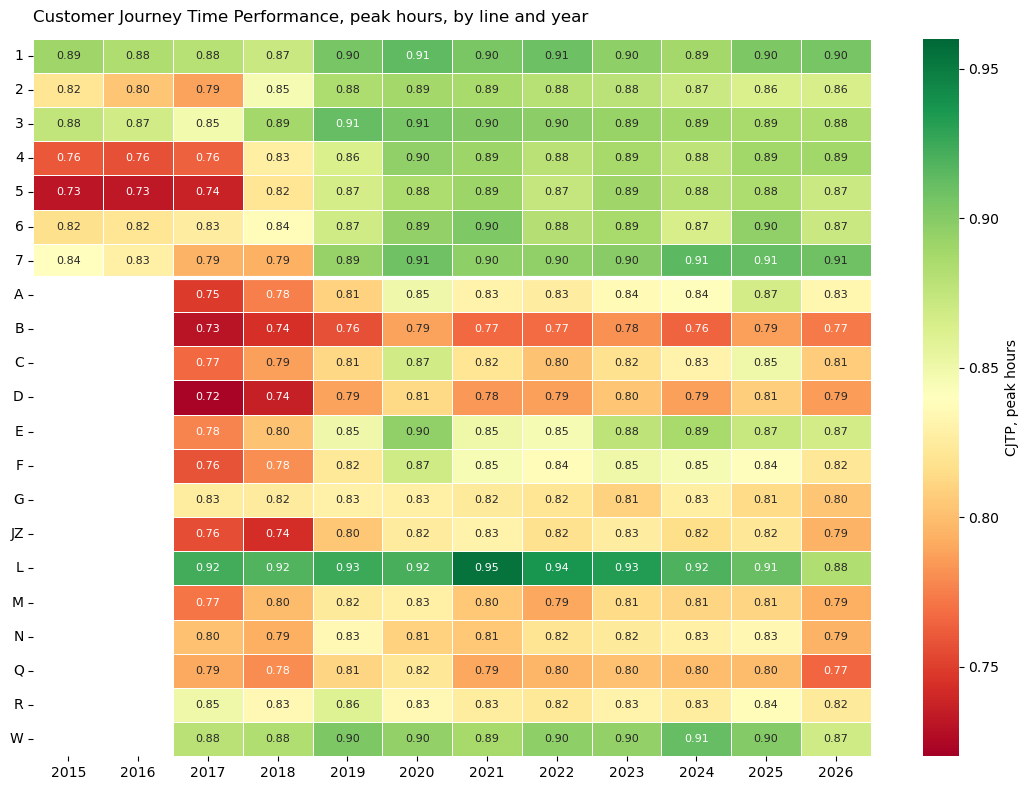

In [6]:
heat_main = heat.drop(index="S 42nd")

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    heat_main,
    cmap="RdYlGn",
    vmin=0.72, vmax=0.96,
    annot=True, fmt=".2f", annot_kws={"size": 8},
    cbar_kws={"label": "CJTP, peak hours"},
    linewidths=0.4, linecolor="white",
    ax=ax,
)
ax.axhline(7, color="white", linewidth=3)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title("Customer Journey Time Performance, peak hours, by line and year",
             loc="left", pad=12)
plt.tight_layout()
fig.savefig(FIGURES / "01_cjtp_heatmap_wip.png", dpi=180, bbox_inches="tight")
fig.savefig(FIGURES / "01_cjtp_heatmap_wip.pdf", bbox_inches="tight")
plt.show()

fig.savefig(FIGURES / "01_cjtp_heatmap_wip.png", dpi=180, bbox_inches="tight")
fig.savefig(FIGURES / "01_cjtp_heatmap_wip.pdf", bbox_inches="tight")

## The pandemic dip that wasn't

CJTP didn't crater in 2020 — it climbed. The naive read is "MTA delivered
better service during a pandemic," which is wrong; the mechanism is that
both ridership and trains fell, and the schedule MTA was being scored
against was thinned. We want to see how durable this artifact is, and
whether the post-2020 trajectory differs across lines.

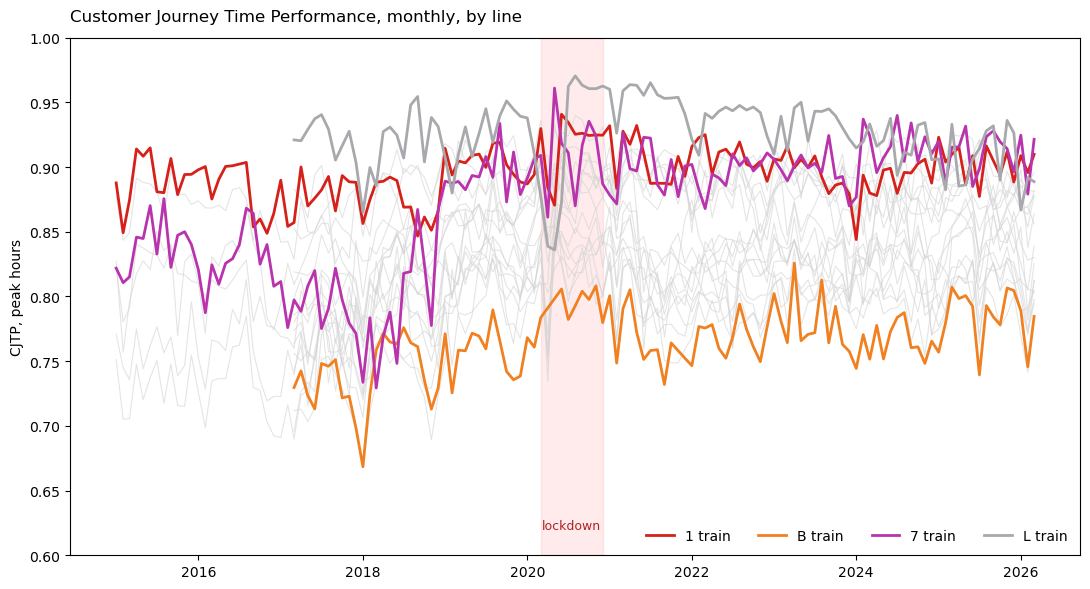

In [7]:
monthly = (
    peak
    .groupby(["line", "month"])["customer_journey_time_performance"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 6))

for line in MAIN_LINES:
    if line == "S 42nd":
        continue
    sub = monthly[monthly["line"] == line]
    ax.plot(sub["month"], sub["customer_journey_time_performance"],
            color="lightgray", linewidth=0.8, alpha=0.6)

for line in ["1", "B", "7", "L"]:
    sub = monthly[monthly["line"] == line]
    ax.plot(sub["month"], sub["customer_journey_time_performance"],
            color=MTA_COLORS[line], linewidth=2, label=f"{line} train")

ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-12-01"),
           color="red", alpha=0.08)
ax.text(pd.Timestamp("2020-07-15"), 0.62, "lockdown",
        ha="center", fontsize=9, color="firebrick")

ax.set_ylim(0.6, 1.0)
ax.set_xlabel("")
ax.set_ylabel("CJTP, peak hours")
ax.set_title("Customer Journey Time Performance, monthly, by line",
             loc="left", pad=12)
ax.legend(loc="lower right", frameon=False, ncol=4)
plt.tight_layout()
plt.show()

In [8]:
fig.savefig(FIGURES / "02_cjtp_timeseries_wip.png", dpi=180, bbox_inches="tight")
fig.savefig(FIGURES / "02_cjtp_timeseries_wip.pdf", bbox_inches="tight")